In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# time (monthly)
n_hist = 48
t = np.arange(n_hist)

# true hyperbolic decline (unknown to ML)
qi_true = 1200
di_true = 0.06
b_true  = 0.9

q_true = qi_true / (1 + b_true * di_true * t)**(1 / b_true)

# add noise
q_obs = q_true + np.random.normal(0, 25, size=n_hist)
q_obs = np.clip(q_obs, 10, None)

df = pd.DataFrame({
    "t": t,
    "q_oil": q_obs
})
df["cum_oil"] = df["q_oil"].cumsum()


In [8]:
def make_features(d):
    d = d.copy()
    d["q_lag1"] = d["q_oil"].shift(1)
    d["q_lag2"] = d["q_oil"].shift(2)
    d["q_lag3"] = d["q_oil"].shift(3)
    return d.dropna().reset_index(drop=True)

df_ml = make_features(df)

X = df_ml[["t", "q_lag1", "q_lag2", "q_lag3", "cum_oil"]]
y = df_ml["q_oil"]


In [9]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=600, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

In [10]:
h = 12
future_rates = []

last = df_ml.iloc[-1]
t0 = int(last["t"])

q1 = float(last["q_oil"])
q2 = float(last["q_lag1"])
q3 = float(last["q_lag2"])
cum = float(df["cum_oil"].iloc[-1])

for i in range(1, h + 1):
    X_next = pd.DataFrame([{
        "t": t0 + i,
        "q_lag1": q1,
        "q_lag2": q2,
        "q_lag3": q3,
        "cum_oil": cum
    }])

    q_next = float(model.predict(X_next)[0])
    q_next = max(q_next, 0)

    future_rates.append(q_next)

    # shift
    q3, q2, q1 = q2, q1, q_next
    cum += q_next


In [11]:
from scipy.optimize import curve_fit

def arps(t, qi, di, b):
    return qi / (1 + b * di * t)**(1 / b)

popt, _ = curve_fit(arps, df["t"], df["q_oil"], p0=[1000, 0.05, 0.8])
qi_hat, di_hat, b_hat = popt

t_fore = np.arange(n_hist, n_hist + h)
q_arps = arps(t_fore, qi_hat, di_hat, b_hat)


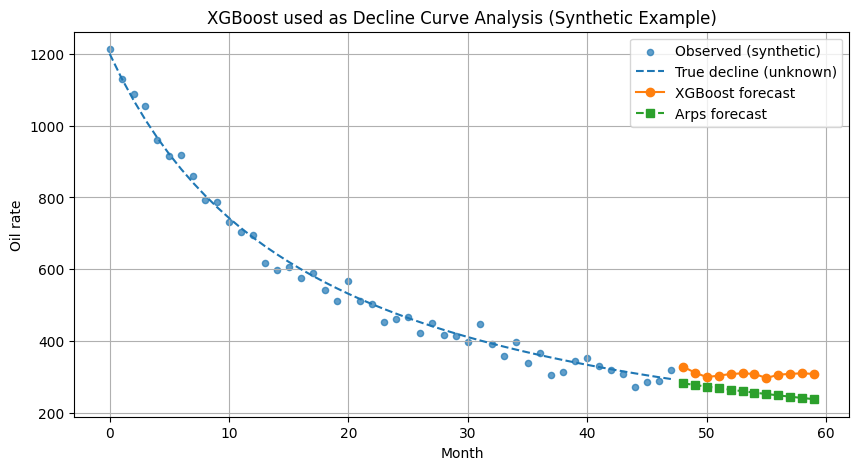

In [12]:
plt.figure(figsize=(10, 5))

plt.scatter(df["t"], df["q_oil"], s=20, label="Observed (synthetic)", alpha=0.7)
plt.plot(df["t"], q_true, "--", label="True decline (unknown)")
plt.plot(t_fore, future_rates, "o-", label="XGBoost forecast")
plt.plot(t_fore, q_arps, "s--", label="Arps forecast")

plt.xlabel("Month")
plt.ylabel("Oil rate")
plt.title("XGBoost used as Decline Curve Analysis (Synthetic Example)")
plt.grid(True)
plt.legend()
plt.show()
